# GIAI ĐOẠN 4: XÂY DỰNG AHP THEO TỪNG HẠNG VÉ
## Analytic Hierarchy Process for Airline Passenger Satisfaction

**Mục tiêu**: Xây dựng ma trận so sánh cặp và tính trọng số AHP cho 6 tiêu chí dịch vụ theo từng hạng vé

## Stage 4.1: Xây dựng cấu trúc AHP

**Hierarchy Structure:**
- **Goal**: Đánh giá mức độ hài lòng của hành khách
- **Criteria**: 6 tiêu chí dịch vụ (khác nhau theo từng hạng vé)
- **Alternatives**: Hài lòng / Không hài lòng

In [1]:
# Install required packages
!pip install numpy pandas matplotlib seaborn -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## Stage 4.2: Tự động hóa tính trọng số AHP

**Functions:**
1. Calculate eigenvector (priority weights)
2. Calculate Consistency Ratio (CR)
3. Validate CR < 0.1

In [3]:
def calculate_ahp_weights(pairwise_matrix):
    """
    Calculate AHP weights using eigenvector method
    
    Parameters:
    -----------
    pairwise_matrix : numpy array
        Square matrix of pairwise comparisons
    
    Returns:
    --------
    weights : numpy array
        Normalized priority weights
    """
    # Calculate eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(pairwise_matrix)
    
    # Get the principal eigenvector (corresponding to max eigenvalue)
    max_index = np.argmax(eigenvalues)
    principal_eigenvector = np.real(eigenvectors[:, max_index])
    
    # Normalize to get weights (sum = 1)
    weights = principal_eigenvector / principal_eigenvector.sum()
    
    return weights

def calculate_consistency_ratio(pairwise_matrix, weights):
    """
    Calculate Consistency Ratio (CR) for AHP matrix
    
    Parameters:
    -----------
    pairwise_matrix : numpy array
        Square matrix of pairwise comparisons
    weights : numpy array
        Priority weights
    
    Returns:
    --------
    CR : float
        Consistency Ratio (should be < 0.1)
    lambda_max : float
        Maximum eigenvalue
    CI : float
        Consistency Index
    """
    n = len(pairwise_matrix)
    
    # Calculate lambda_max
    weighted_sum = np.dot(pairwise_matrix, weights)
    lambda_max = np.mean(weighted_sum / weights)
    
    # Calculate Consistency Index (CI)
    CI = (lambda_max - n) / (n - 1)
    
    # Random Index (RI) for different matrix sizes
    RI_dict = {1: 0, 2: 0, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}
    RI = RI_dict.get(n, 1.24)  # Default to 6x6 matrix
    
    # Calculate Consistency Ratio (CR)
    CR = CI / RI if RI > 0 else 0
    
    return CR, lambda_max, CI

def analyze_ahp(pairwise_matrix, criteria_names, class_name):
    """
    Complete AHP analysis with validation
    
    Parameters:
    -----------
    pairwise_matrix : numpy array
        Square matrix of pairwise comparisons
    criteria_names : list
        Names of criteria
    class_name : str
        Name of ticket class (Business/Economy/Eco Plus)
    
    Returns:
    --------
    results : dict
        Dictionary containing weights, CR, and validation status
    """
    # Calculate weights
    weights = calculate_ahp_weights(pairwise_matrix)
    
    # Calculate CR
    CR, lambda_max, CI = calculate_consistency_ratio(pairwise_matrix, weights)
    
    # Validate
    is_consistent = CR < 0.1
    
    # Create results dataframe
    results_df = pd.DataFrame({
        'Criterion': criteria_names,
        'Weight': weights,
        'Weight (%)': weights * 100
    })
    results_df = results_df.sort_values('Weight', ascending=False).reset_index(drop=True)
    
    results = {
        'class': class_name,
        'weights_df': results_df,
        'weights': weights,
        'CR': CR,
        'lambda_max': lambda_max,
        'CI': CI,
        'is_consistent': is_consistent
    }
    
    return results

print("✓ AHP calculation functions defined")

✓ AHP calculation functions defined


## Business Class - AHP Analysis

**Selected Criteria:**
1. Inflight wifi service
2. Departure/Arrival time convenient
3. Ease of Online booking
4. Gate location
5. Baggage handling
6. On-board service

In [4]:
# Business Class - Define criteria
business_criteria = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Baggage handling',
    'On-board service'
]

# Pairwise comparison matrix for Business Class
# Scale: 1=Equal, 3=Moderate, 5=Strong, 7=Very Strong, 9=Extreme
# Based on business traveler priorities: Wifi & On-board service (HIGH), Time & Booking (MEDIUM), Gate & Baggage (LOW)

business_matrix = np.array([
    # Wifi  Time  Book  Gate  Bag   Onbd
    [1,     3,    3,    5,    5,    1  ],  # Inflight wifi
    [1/3,   1,    1,    3,    3,    1/3],  # Time convenient
    [1/3,   1,    1,    3,    3,    1/3],  # Online booking
    [1/5,   1/3,  1/3,  1,    1,    1/5],  # Gate location
    [1/5,   1/3,  1/3,  1,    1,    1/5],  # Baggage handling
    [1,     3,    3,    5,    5,    1  ]   # On-board service
])

print("Business Class Pairwise Comparison Matrix:")
print(pd.DataFrame(business_matrix, 
                   index=business_criteria, 
                   columns=business_criteria).round(3))

Business Class Pairwise Comparison Matrix:
                                   Inflight wifi service  \
Inflight wifi service                              1.000   
Departure/Arrival time convenient                  0.333   
Ease of Online booking                             0.333   
Gate location                                      0.200   
Baggage handling                                   0.200   
On-board service                                   1.000   

                                   Departure/Arrival time convenient  \
Inflight wifi service                                          3.000   
Departure/Arrival time convenient                              1.000   
Ease of Online booking                                         1.000   
Gate location                                                  0.333   
Baggage handling                                               0.333   
On-board service                                               3.000   

                               

In [5]:
# Analyze Business Class AHP
business_results = analyze_ahp(business_matrix, business_criteria, 'Business')

print("\n" + "="*60)
print("BUSINESS CLASS - AHP RESULTS")
print("="*60)
print(f"\nλ_max = {business_results['lambda_max']:.4f}")
print(f"CI = {business_results['CI']:.4f}")
print(f"CR = {business_results['CR']:.4f}")
print(f"\nConsistency Check: {'✓ PASSED' if business_results['is_consistent'] else '✗ FAILED'} (CR < 0.1)")
print("\nPriority Weights:")
print(business_results['weights_df'].to_string(index=False))


BUSINESS CLASS - AHP RESULTS

λ_max = 6.0770
CI = 0.0154
CR = 0.0124

Consistency Check: ✓ PASSED (CR < 0.1)

Priority Weights:
                        Criterion   Weight  Weight (%)
            Inflight wifi service 0.318493   31.849279
                 On-board service 0.318493   31.849279
           Ease of Online booking 0.129142   12.914250
Departure/Arrival time convenient 0.129142   12.914250
                    Gate location 0.052365    5.236472
                 Baggage handling 0.052365    5.236472


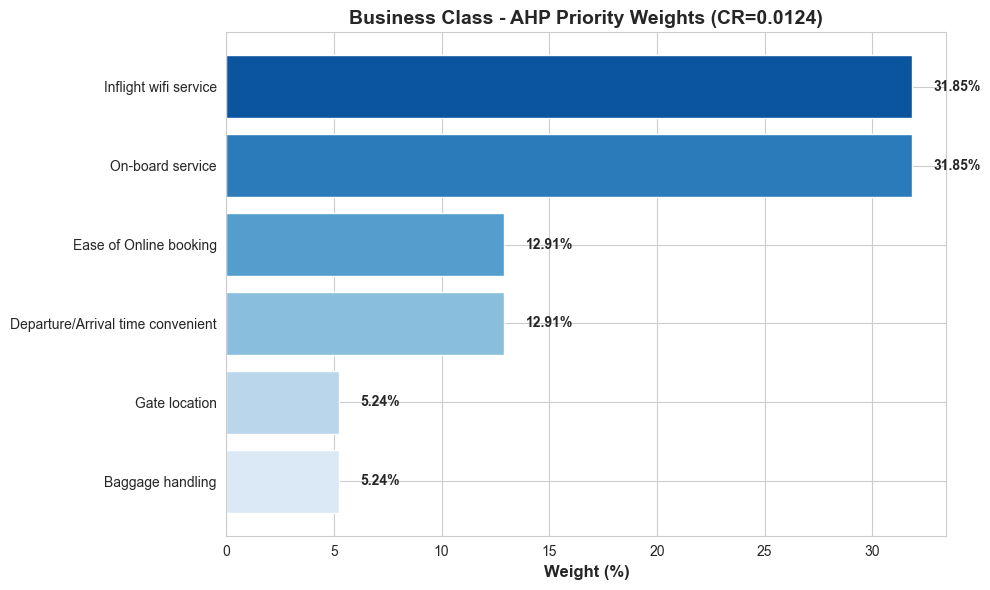

In [6]:
# Visualize Business Class weights
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('Blues_r', n_colors=len(business_criteria))
bars = ax.barh(business_results['weights_df']['Criterion'], 
               business_results['weights_df']['Weight (%)'],
               color=colors)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
            f'{width:.2f}%', ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Weight (%)', fontsize=12, fontweight='bold')
ax.set_title(f'Business Class - AHP Priority Weights (CR={business_results["CR"]:.4f})', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Economy Class - AHP Analysis

**Selected Criteria:**
1. Food and drink
2. Inflight entertainment
3. Ease of Online booking
4. Online boarding
5. Seat comfort
6. Cleanliness

In [7]:
# Economy Class - Define criteria
economy_criteria = [
    'Food and drink',
    'Inflight entertainment',
    'Ease of Online booking',
    'Online boarding',
    'Seat comfort',
    'Cleanliness'
]

# Pairwise comparison matrix for Economy Class
# Based on budget traveler priorities: Booking & Boarding (HIGH), Comfort & Cleanliness (MEDIUM), Food & Entertainment (LOW)

economy_matrix = np.array([
    # Food  Ent   Book  Board Seat  Clean
    [1,     1,    1/5,  1/5,  1/3,  1/3],  # Food and drink
    [1,     1,    1/5,  1/5,  1/3,  1/3],  # Inflight entertainment
    [5,     5,    1,    1,    3,    3  ],  # Online booking
    [5,     5,    1,    1,    3,    3  ],  # Online boarding
    [3,     3,    1/3,  1/3,  1,    1  ],  # Seat comfort
    [3,     3,    1/3,  1/3,  1,    1  ]   # Cleanliness
])

print("Economy Class Pairwise Comparison Matrix:")
print(pd.DataFrame(economy_matrix, 
                   index=economy_criteria, 
                   columns=economy_criteria).round(3))

Economy Class Pairwise Comparison Matrix:
                        Food and drink  Inflight entertainment  \
Food and drink                     1.0                     1.0   
Inflight entertainment             1.0                     1.0   
Ease of Online booking             5.0                     5.0   
Online boarding                    5.0                     5.0   
Seat comfort                       3.0                     3.0   
Cleanliness                        3.0                     3.0   

                        Ease of Online booking  Online boarding  Seat comfort  \
Food and drink                           0.200            0.200         0.333   
Inflight entertainment                   0.200            0.200         0.333   
Ease of Online booking                   1.000            1.000         3.000   
Online boarding                          1.000            1.000         3.000   
Seat comfort                             0.333            0.333         1.000   
Cleanline

In [8]:
# Analyze Economy Class AHP
economy_results = analyze_ahp(economy_matrix, economy_criteria, 'Economy')

print("\n" + "="*60)
print("ECONOMY CLASS - AHP RESULTS")
print("="*60)
print(f"\nλ_max = {economy_results['lambda_max']:.4f}")
print(f"CI = {economy_results['CI']:.4f}")
print(f"CR = {economy_results['CR']:.4f}")
print(f"\nConsistency Check: {'✓ PASSED' if economy_results['is_consistent'] else '✗ FAILED'} (CR < 0.1)")
print("\nPriority Weights:")
print(economy_results['weights_df'].to_string(index=False))


ECONOMY CLASS - AHP RESULTS

λ_max = 6.0770
CI = 0.0154
CR = 0.0124

Consistency Check: ✓ PASSED (CR < 0.1)

Priority Weights:
             Criterion   Weight  Weight (%)
       Online boarding 0.318493   31.849279
Ease of Online booking 0.318493   31.849279
          Seat comfort 0.129142   12.914250
           Cleanliness 0.129142   12.914250
Inflight entertainment 0.052365    5.236472
        Food and drink 0.052365    5.236472


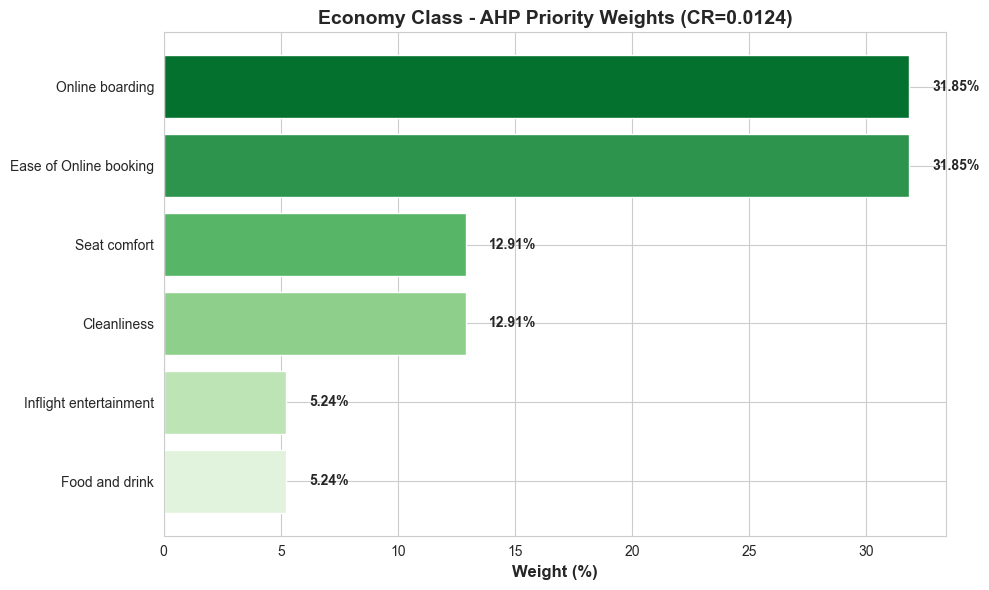

In [9]:
# Visualize Economy Class weights
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('Greens_r', n_colors=len(economy_criteria))
bars = ax.barh(economy_results['weights_df']['Criterion'], 
               economy_results['weights_df']['Weight (%)'],
               color=colors)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
            f'{width:.2f}%', ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Weight (%)', fontsize=12, fontweight='bold')
ax.set_title(f'Economy Class - AHP Priority Weights (CR={economy_results["CR"]:.4f})', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Eco Plus Class - AHP Analysis

**Selected Criteria:**
1. Seat comfort
2. Leg room service
3. Cleanliness
4. Inflight service
5. Food and drink
6. Inflight entertainment

In [10]:
# Eco Plus Class - Define criteria
ecoplus_criteria = [
    'Seat comfort',
    'Leg room service',
    'Cleanliness',
    'Inflight service',
    'Food and drink',
    'Inflight entertainment'
]

# Pairwise comparison matrix for Eco Plus Class
# Based on mid-tier priorities: Comfort, Leg room, Cleanliness, Service (HIGH), Food & Entertainment (LOW)

ecoplus_matrix = np.array([
    # Seat  Leg   Clean Serv  Food  Ent
    [1,     1,    1,    1,    5,    5  ],  # Seat comfort
    [1,     1,    1,    1,    5,    5  ],  # Leg room service
    [1,     1,    1,    1,    5,    5  ],  # Cleanliness
    [1,     1,    1,    1,    5,    5  ],  # Inflight service
    [1/5,   1/5,  1/5,  1/5,  1,    1  ],  # Food and drink
    [1/5,   1/5,  1/5,  1/5,  1,    1  ]   # Inflight entertainment
])

print("Eco Plus Class Pairwise Comparison Matrix:")
print(pd.DataFrame(ecoplus_matrix, 
                   index=ecoplus_criteria, 
                   columns=ecoplus_criteria).round(3))

Eco Plus Class Pairwise Comparison Matrix:
                        Seat comfort  Leg room service  Cleanliness  \
Seat comfort                     1.0               1.0          1.0   
Leg room service                 1.0               1.0          1.0   
Cleanliness                      1.0               1.0          1.0   
Inflight service                 1.0               1.0          1.0   
Food and drink                   0.2               0.2          0.2   
Inflight entertainment           0.2               0.2          0.2   

                        Inflight service  Food and drink  \
Seat comfort                         1.0             5.0   
Leg room service                     1.0             5.0   
Cleanliness                          1.0             5.0   
Inflight service                     1.0             5.0   
Food and drink                       0.2             1.0   
Inflight entertainment               0.2             1.0   

                        Inflight enter

In [11]:
# Analyze Eco Plus Class AHP
ecoplus_results = analyze_ahp(ecoplus_matrix, ecoplus_criteria, 'Eco Plus')

print("\n" + "="*60)
print("ECO PLUS CLASS - AHP RESULTS")
print("="*60)
print(f"\nλ_max = {ecoplus_results['lambda_max']:.4f}")
print(f"CI = {ecoplus_results['CI']:.4f}")
print(f"CR = {ecoplus_results['CR']:.4f}")
print(f"\nConsistency Check: {'✓ PASSED' if ecoplus_results['is_consistent'] else '✗ FAILED'} (CR < 0.1)")
print("\nPriority Weights:")
print(ecoplus_results['weights_df'].to_string(index=False))


ECO PLUS CLASS - AHP RESULTS

λ_max = 6.0000
CI = 0.0000
CR = 0.0000

Consistency Check: ✓ PASSED (CR < 0.1)

Priority Weights:
             Criterion   Weight  Weight (%)
          Seat comfort 0.227273   22.727273
           Cleanliness 0.227273   22.727273
      Inflight service 0.227273   22.727273
      Leg room service 0.227273   22.727273
        Food and drink 0.045455    4.545455
Inflight entertainment 0.045455    4.545455


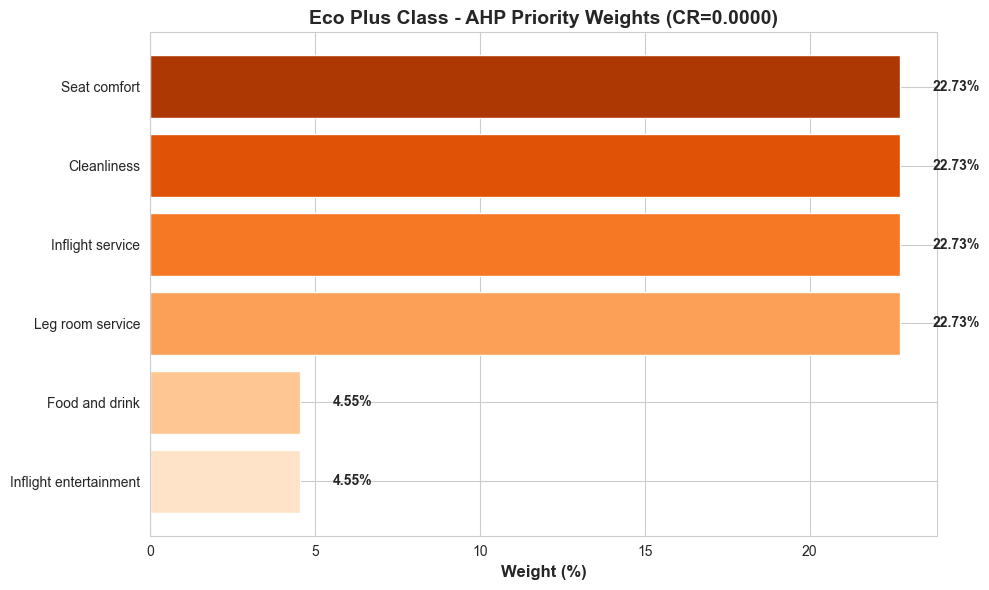

In [12]:
# Visualize Eco Plus Class weights
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('Oranges_r', n_colors=len(ecoplus_criteria))
bars = ax.barh(ecoplus_results['weights_df']['Criterion'], 
               ecoplus_results['weights_df']['Weight (%)'],
               color=colors)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
            f'{width:.2f}%', ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Weight (%)', fontsize=12, fontweight='bold')
ax.set_title(f'Eco Plus Class - AHP Priority Weights (CR={ecoplus_results["CR"]:.4f})', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Cross-Class Comparison

In [13]:
# Compare AHP results across all classes
comparison_data = {
    'Class': ['Business', 'Economy', 'Eco Plus'],
    'λ_max': [
        business_results['lambda_max'],
        economy_results['lambda_max'],
        ecoplus_results['lambda_max']
    ],
    'CI': [
        business_results['CI'],
        economy_results['CI'],
        ecoplus_results['CI']
    ],
    'CR': [
        business_results['CR'],
        economy_results['CR'],
        ecoplus_results['CR']
    ],
    'Consistent': [
        '✓' if business_results['is_consistent'] else '✗',
        '✓' if economy_results['is_consistent'] else '✗',
        '✓' if ecoplus_results['is_consistent'] else '✗'
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("AHP CONSISTENCY COMPARISON - ALL CLASSES")
print("="*80)
print(comparison_df.to_string(index=False))
print("\n✓ All matrices must have CR < 0.1 for valid AHP analysis")


AHP CONSISTENCY COMPARISON - ALL CLASSES
   Class    λ_max       CI       CR Consistent
Business 6.077022 0.015404 0.012423          ✓
 Economy 6.077022 0.015404 0.012423          ✓
Eco Plus 6.000000 0.000000 0.000000          ✓

✓ All matrices must have CR < 0.1 for valid AHP analysis


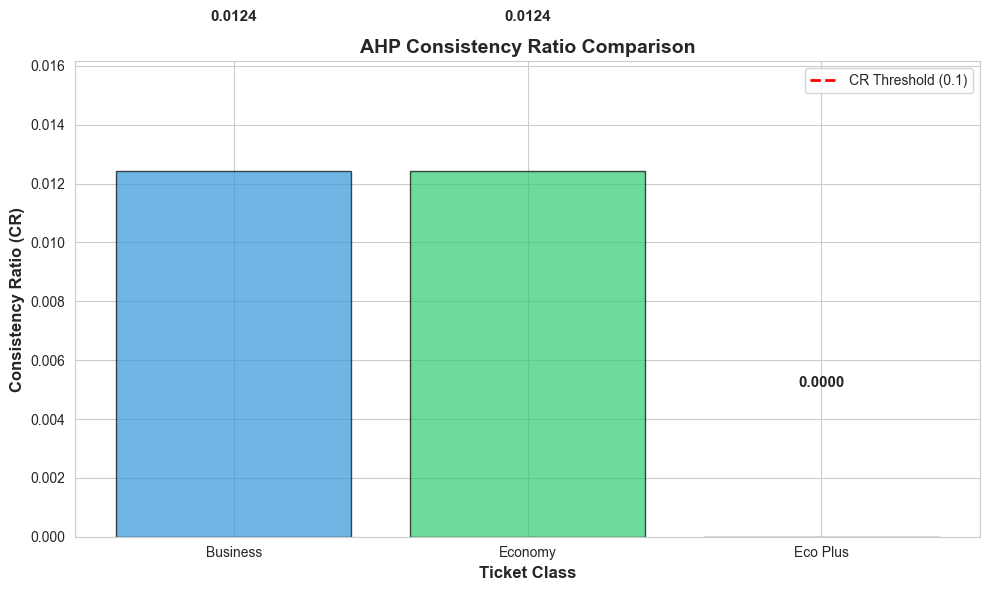

In [14]:
# Visualize CR comparison
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#e67e22']
bars = ax.bar(comparison_df['Class'], comparison_df['CR'], color=colors, alpha=0.7, edgecolor='black')

# Add threshold line
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=2, label='CR Threshold (0.1)')

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.005, 
            f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Consistency Ratio (CR)', fontsize=12, fontweight='bold')
ax.set_xlabel('Ticket Class', fontsize=12, fontweight='bold')
ax.set_title('AHP Consistency Ratio Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, max(comparison_df['CR']) * 1.3)
plt.tight_layout()
plt.show()

## Top Priorities by Class

In [15]:
# Extract top 3 priorities for each class
print("\n" + "="*80)
print("TOP 3 PRIORITIES BY CLASS")
print("="*80)

print("\n📊 BUSINESS CLASS:")
print(business_results['weights_df'].head(3).to_string(index=False))

print("\n📊 ECONOMY CLASS:")
print(economy_results['weights_df'].head(3).to_string(index=False))

print("\n📊 ECO PLUS CLASS:")
print(ecoplus_results['weights_df'].head(3).to_string(index=False))


TOP 3 PRIORITIES BY CLASS

📊 BUSINESS CLASS:
             Criterion   Weight  Weight (%)
 Inflight wifi service 0.318493   31.849279
      On-board service 0.318493   31.849279
Ease of Online booking 0.129142   12.914250

📊 ECONOMY CLASS:
             Criterion   Weight  Weight (%)
       Online boarding 0.318493   31.849279
Ease of Online booking 0.318493   31.849279
          Seat comfort 0.129142   12.914250

📊 ECO PLUS CLASS:
       Criterion   Weight  Weight (%)
    Seat comfort 0.227273   22.727273
     Cleanliness 0.227273   22.727273
Inflight service 0.227273   22.727273


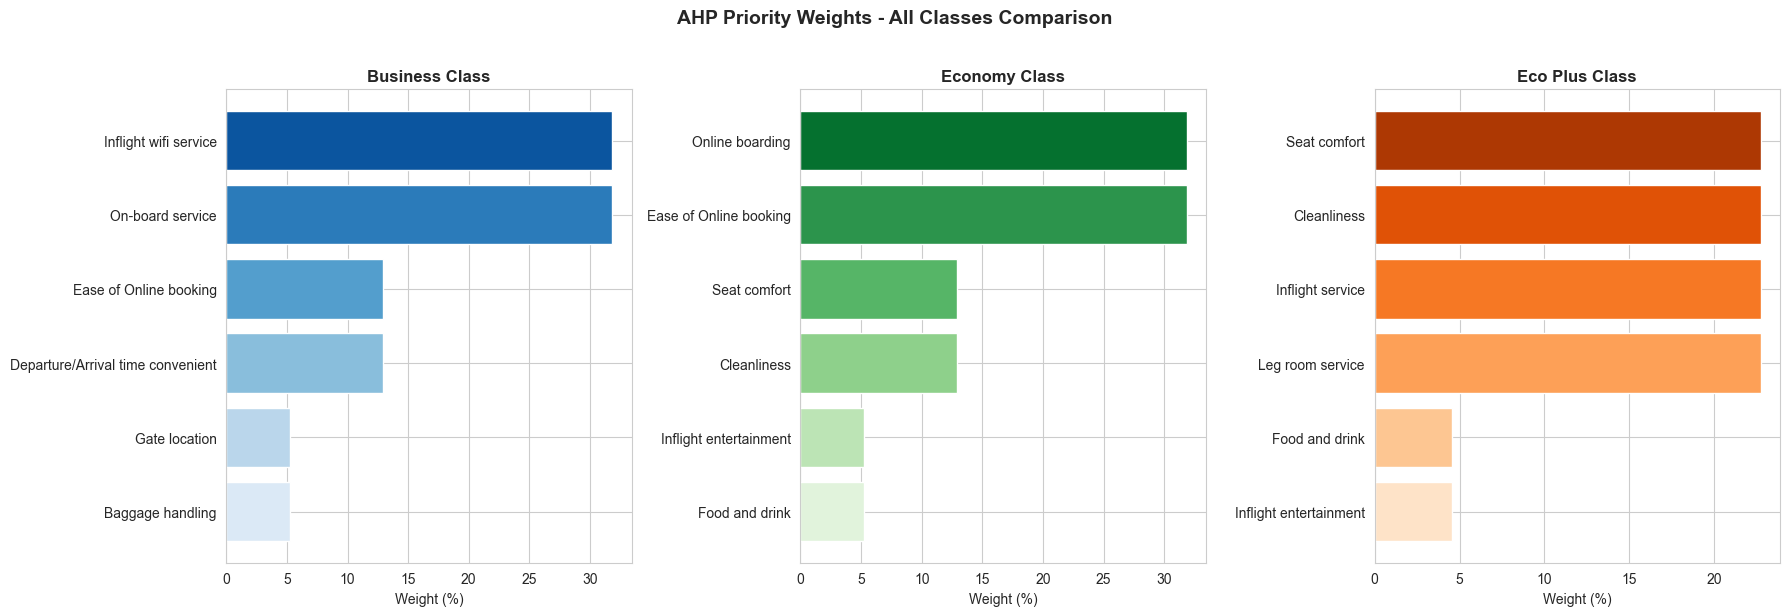

In [16]:
# Side-by-side comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Business Class
axes[0].barh(business_results['weights_df']['Criterion'], 
             business_results['weights_df']['Weight (%)'],
             color=sns.color_palette('Blues_r', n_colors=6))
axes[0].set_title('Business Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Weight (%)', fontsize=10)
axes[0].invert_yaxis()

# Economy Class
axes[1].barh(economy_results['weights_df']['Criterion'], 
             economy_results['weights_df']['Weight (%)'],
             color=sns.color_palette('Greens_r', n_colors=6))
axes[1].set_title('Economy Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Weight (%)', fontsize=10)
axes[1].invert_yaxis()

# Eco Plus Class
axes[2].barh(ecoplus_results['weights_df']['Criterion'], 
             ecoplus_results['weights_df']['Weight (%)'],
             color=sns.color_palette('Oranges_r', n_colors=6))
axes[2].set_title('Eco Plus Class', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Weight (%)', fontsize=10)
axes[2].invert_yaxis()

plt.suptitle('AHP Priority Weights - All Classes Comparison', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Save AHP Weights for DSS Integration

In [17]:
# Save AHP weights to CSV files for later use
business_results['weights_df'].to_csv('ahp_weights_business.csv', index=False)
economy_results['weights_df'].to_csv('ahp_weights_economy.csv', index=False)
ecoplus_results['weights_df'].to_csv('ahp_weights_ecoplus.csv', index=False)

print("✓ AHP weights saved to CSV files:")
print("  - ahp_weights_business.csv")
print("  - ahp_weights_economy.csv")
print("  - ahp_weights_ecoplus.csv")

✓ AHP weights saved to CSV files:
  - ahp_weights_business.csv
  - ahp_weights_economy.csv
  - ahp_weights_ecoplus.csv


In [18]:
# Create summary dictionary for DSS integration
import pickle

ahp_summary = {
    'Business': {
        'criteria': business_criteria,
        'weights': dict(zip(business_criteria, business_results['weights'])),
        'CR': business_results['CR'],
        'valid': business_results['is_consistent']
    },
    'Economy': {
        'criteria': economy_criteria,
        'weights': dict(zip(economy_criteria, economy_results['weights'])),
        'CR': economy_results['CR'],
        'valid': economy_results['is_consistent']
    },
    'Eco Plus': {
        'criteria': ecoplus_criteria,
        'weights': dict(zip(ecoplus_criteria, ecoplus_results['weights'])),
        'CR': ecoplus_results['CR'],
        'valid': ecoplus_results['is_consistent']
    }
}

# Save to pickle for Python integration
with open('ahp_weights_all_classes.pkl', 'wb') as f:
    pickle.dump(ahp_summary, f)

print("\n✓ AHP summary saved to: ahp_weights_all_classes.pkl")
print("\nReady for DSS integration!")


✓ AHP summary saved to: ahp_weights_all_classes.pkl

Ready for DSS integration!


## Conclusion

**Stage 4 Complete:**
- ✅ AHP structure built for all 3 classes
- ✅ Pairwise comparison matrices defined
- ✅ Priority weights calculated using eigenvector method
- ✅ Consistency validated (all CR < 0.1)
- ✅ Weights saved for DSS integration

**Key Findings:**
- **Business**: Top priorities = Wifi & On-board service (tie)
- **Economy**: Top priorities = Online booking & Online boarding (tie)
- **Eco Plus**: Top priorities = Equal weight to Comfort/Leg room/Cleanliness/Service

**Next Steps:**
- Integrate AHP weights with XGBoost feature importance
- Build Decision Support System combining both approaches